In [5]:
import os
from dotenv import load_dotenv

load_dotenv()

True

In [6]:
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")

In [8]:
from langchain_openai import ChatOpenAI 

llm= ChatOpenAI(model="gpt-4o")
llm.invoke("Hi")

AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 8, 'total_tokens': 17, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_07871e2ad8', 'id': 'chatcmpl-Bl9kwGNF7wWQztzMeJwl3RJQi7M0S', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--18c07d8d-deb2-45ad-a2e5-a6a6e21440ce-0', usage_metadata={'input_tokens': 8, 'output_tokens': 9, 'total_tokens': 17, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [11]:
from langgraph.types import Command

In [12]:
from langgraph.prebuilt import create_react_agent

In [15]:
def add_number(state):
    result= state["num1"] + state["num2"]
    print(f"addition is {result}")
    return Command(goto="multiply", update={"sum":result})

In [18]:
state= {"num1": 10, "num2": 20}
state

{'num1': 10, 'num2': 20}

In [19]:
add_number(state)

addition is 30


Command(update={'sum': 30}, goto='multiply')

### Creating one dummy multiagent

It is for network/collabrating multiagent.

In [20]:
from langchain_core.tools import tool

In [23]:
@tool
def transfer_to_multiplication_expert():
    """Ask multiplication agent for help"""
    
    return

In [24]:
@tool
def transfer_to_addition_expert():
    """Ask addition agent for help"""
    
    return

In [35]:
llm_with_tool= llm.bind_tools([transfer_to_addition_expert])

In [27]:
response= llm_with_tool.invoke("Hi")
response.content

'Hello! How can I assist you today?'

In [28]:
response.tool_calls

[]

In [36]:
response= llm_with_tool.invoke("what is 2+2?")
response.content

''

In [37]:
response.tool_calls 

[{'name': 'transfer_to_addition_expert',
  'args': {},
  'id': 'call_Bcmb26JbDCOyIWsFa8qXSRrW',
  'type': 'tool_call'}]

In [43]:
from typing_extensions import Literal
from langgraph.graph import MessagesState, StateGraph, START, END

In [78]:
system_prompt= (
        "You are an addition expert, you can ask the multiplication expert for help with multiplication."
        "Always do your portion of calculation before the handoff."
    )

In [79]:
messages= [{"role": "system", "content": system_prompt}] + ["can you tell me the addition of 2 and 2?"]

In [80]:
messages

[{'role': 'system',
  'content': 'You are an addition expert, you can ask the multiplication expert for help with multiplication.Always do your portion of calculation before the handoff.'},
 'can you tell me the addition of 2 and 2?']

In [71]:
# Agent1 
def additional_expert(state: MessagesState) -> Command[Literal["multiplication_expert", "__end__"]]:
    system_prompt= (
        "You are an addition expert, you can ask the multiplication expert for help with multiplication."
        "Always do your portion of calculation before the handoff."
    )

    messages= [{"role": "system", "content": system_prompt}] + state["messages"]

    ai_msg= llm.bind_tools([transfer_to_multiplication_expert]).invoke(messages)

    if len(ai_msg.tool_calls) > 0:
        tool_call_id= ai_msg.tool_calls[-1]["id"]
        tool_msg= {
            "role": "tool",
            "content": "Successfully transferred",
            "tool_call_id": tool_call_id,
        }

        return Command(goto="multiplication_expert", update={"messages": [ai_msg, tool_msg]})
    
    return {"messages": [ai_msg]}

In [70]:
# Agent2
def multiplication_expert(state: MessagesState) -> Command[Literal["additional_expert", "__end__"]]:
    system_prompt= (
        "You are a multiplication expert, you can ask an addition expert for help with addition."
        "Always do your portion of calculation before the handoff."
    )

    messages= [{"role": "system", "content": system_prompt}] + state["messages"]

    ai_msg= llm.bind_tools([transfer_to_addition_expert]).invoke(messages)

    if len(ai_msg.tool_calls) > 0:
        tool_call_id = ai_msg.tool_calls[-1]["id"]
        tool_msg= {
            "role": "tool",
            "content": "Successfully transferred",
            "tool_call_id": tool_call_id,
        }

        return Command(goto="additional_expert", update={"messages": [ai_msg, tool_msg]}) 
    return {"messages": [ai_msg]}

In [72]:
graph= StateGraph(MessagesState)

In [73]:
graph.add_node("additional_expert", additional_expert)
graph.add_node("multiplication_expert", multiplication_expert)

In [74]:
graph.add_edge(START, "additional_expert")
# graph.add_edge("multiplication_expert", "additional_expert")

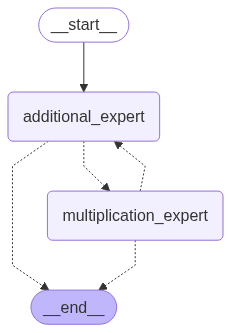

In [60]:
graph.compile()

In [75]:
app= graph.compile()

In [81]:
app.invoke({"messages":[("user","what's (3 + 5) * 12. Provide me the output")]})

{'messages': [HumanMessage(content="what's (3 + 5) * 12. Provide me the output", additional_kwargs={}, response_metadata={}, id='f373b487-c67c-48b3-b692-5a48f1adc3aa'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_pKmpZ4baiocYiO6wMj9aFpMq', 'function': {'arguments': '{}', 'name': 'transfer_to_multiplication_expert'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 86, 'total_tokens': 101, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_07871e2ad8', 'id': 'chatcmpl-BlBJhPMmF0OatWIweAiO0yKYUDHLn', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--4b6e29b1-188a-49a9-9b75-9f1c8b916631-0', tool_calls=[{'name': 'transfer_to_multiplication_expert', 

### With Realtime tool